# GLM: 1st-level Analysis

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/BIMAI-lab/NEUROML_course/blob/main/seminars6_7/IndividualAnalysis.ipynb)

The objective in this example is to model the timecourse of each voxel. This will allow us to answer question regarding to the voxel response to different stimuli. 

We will model the activation at each voxel $y$ as a weighed sum of explanatory variables $x_{i}$ 
and error term ${\epsilon}$

$${y} = {\beta}_{0} + \sum \limits _{i=1} ^{N} x_{i}{\beta}_{i} + {\epsilon} $$

or in matrix notation

$$ y = X\beta + {\epsilon} $$

which can be solved with Ordinary Least Squares regression.

The parameters ${\beta}$ represent the contribution of each variable to the voxel activation.

The error terms are assumed to be independent and identically distributed.

![Design matrix](https://mri-q.com/uploads/3/4/5/7/34572113/9355842_orig.jpg)

The matrix  𝑋  is also called design matrix. It is up to the researcher which factors to include in the design matrix. The design matrix contains factors that a related to the hypothesis the researcher want to answer. Furthermore, sometimes in it are also included factors that are not related to the hypothesis, but are know sources of variability (nuisance factors).

### Hemodynamic response

Now lets take a look how we take into account the delayed Blood-Oxygen-Level-Dependent (BOLD) response.
The [hemodynamic response function](https://en.wikipedia.org/wiki/Haemodynamic_response) might look something like this:

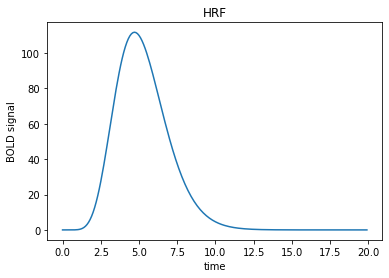

In [1]:
import numpy as np 
import matplotlib.pyplot as plt


def hrf(t):
    return t ** 8.6 * np.exp(-t / 0.547)

hrf_times = np.arange(0, 20, 0.1)
hrf_signal = hrf(hrf_times)
plt.plot(hrf_times, hrf_signal)
plt.xlabel('time')
plt.ylabel('BOLD signal')
_ = plt.title('HRF')

In the design often we want to include variables, that indicate presence or absence of a stimuli.
Let's say we had the 3 stimuli during the timecourse

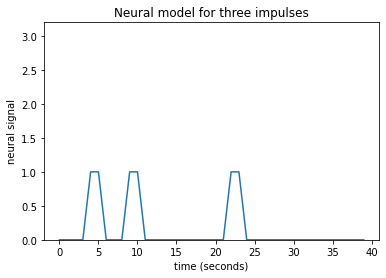

In [2]:
n_time_points = 40

times = np.arange(0, n_time_points)  

neural_signal = np.zeros(n_time_points)
neural_signal[4:6] = 1  # A 3 second event
neural_signal[9:11] = 1
neural_signal[22:24] = 1

plt.plot(times, neural_signal)
plt.xlabel('time (seconds)')
plt.ylabel('neural signal')
plt.ylim(0, 3.2)
_ = plt.title('Neural model for three impulses')

Next we have to [convolve](https://en.wikipedia.org/wiki/Convolution) signal with our hrf function

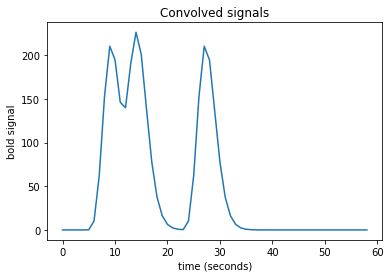

In [3]:
hrf_times = np.arange(20)
hrf_signal = hrf(hrf_times)
bold_signal = np.convolve(neural_signal, hrf_signal)

tailed_respose_times = np.arange(n_time_points + hrf_times.shape[0] - 1)
plt.plot(tailed_respose_times, bold_signal)
plt.xlabel('time (seconds)')
plt.ylabel('bold signal')
_ = plt.title('Convolved signals')

After that we can fit our fMRI data to the design Matrix and use GLM for hypotesis testing.
We can evaluate whether a given factor $i$ has a **considerable contribution** by its coefficient ${\beta}_{i}$.
With t-test we can evaluate whether ${\beta}_{i}$ > 0. We can also test hypothesis of the form ${\beta}_{i}$ > ${\beta}_{j}$.

The general form of the hypothesis tests which forms a **contrast** is:
$$\sum \limits _{i=1} ^{P} c_{i}{\beta}_{i} > 0 $$

Typical values for $c$ are 1 and -1.
Typically contrasts are express as: $[c_{1}, c_{2}, ..., c_{N}]$.

> For example the contrast [1, 0] tests ${\beta}_{1}$ > 0.

This contrasts form a **t-statistics** (Recall that $\frac{c^T \beta}{SE(c^T \beta)}$ in OLS regression follow $t$-distribution with $n-p-1$ degrees of freedom).

We can combine several contrasts and form **F-statistics**. In the contexts of fMRI the F-tests help us answer questions like "*Is effect A or effect B or effect C, or any combination of them, significantly non-zero?*".

Recall that F-test is used for comparison between reduced model $RF$ and full model $FM$:
$$ F = \frac{(SSE(RM)-SSE(FM)) /(k_{FM}-k_{RM}))}{SSE(FM)/(n-k_{FM})} $$

where $SSE$ - the sum of squared errors, $n$ - number of time points, $k$ - the number of model distinct parameters.


Combining the test results from all voxels we get statistical map of brain activity.
Now that the theory out of our way we can see how it is done in Nipype.


# 1st Level Analysis in Nipype

We will use the preprocessed files generated in the previous step and perform a **first‑level (single‑subject) GLM analysis** for each participant. The analysis will follow this steps:

1. Extract stimulus **onsets**, **durations**, and **condition labels** (Finger, Foot, Lips) from the `task-fingerfootlips_events.tsv` file. 

2. Build the design matrix
    - Set key parameters of SPM model
    - Include **nuisance regressors**
    - **Convolve** the event regressors with the **canonical HRF** to model the hemodynamic response shape.  
    
3. Estimate the GLM  
    - Solve the equation $y = X·β + ε$ for each voxel using **ordinary least squares (OLS)**.  
    - Obtain **beta maps** – the estimated contribution of each predictor to the BOLD signal.
    
4. Define and estimate contrasts 
    - Specify a set of **T‑contrasts** to test directed hypotheses:  
      - Average activation across all three conditions (Finger + Foot + Lips).  
      - Each condition separately (Finger, Foot, Lips).    
    - Specify an **F‑contrast** to test for **any** condition effect.  
    - Compute **statistical maps** (T‑maps and F‑maps) and **effect size** maps.
    
5. Store results for each subject.

6. Visualise and quality‑check  

In [6]:
import pandas as pd
import os

from nilearn import plotting
%matplotlib inline


from nipype.interfaces.spm import Level1Design, EstimateModel, EstimateContrast
from nipype.algorithms.modelgen import SpecifySPMModel
from nipype.interfaces.utility import Function, IdentityInterface
from nipype.interfaces.io import SelectFiles, DataSink
from nipype import Workflow, Node
from utils import list_files

In [7]:
# specify paths
experiment_dir = '/output'
output_dir = 'datasink'
working_dir = 'workingdir'

# list of subject identifiers
subject_list = ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10']

# subject_list = ['01', '02']
# Repetition time(TR) of functional images
TR = 2.5

> **Question:** What is Repetition time (TR) and why it is important? How to get this value?

## Prepare design matrix
Let's take a look how the stimuli onset and duration look like.This information is store in a ``tsv`` file. This file will help us build the design matrix.

The three different conditions in the **fingerfootlips** task are:
- **finger**
- **foot**
- **lips**

In [10]:
trialinfo = pd.read_table('/data/ds000114/task-fingerfootlips_events.tsv')
trialinfo.head()

,onset,duration,weight,trial_type
0,10,15.0,1,Finger
1,40,15.0,1,Foot
2,70,15.0,1,Lips
3,100,15.0,1,Finger
4,130,15.0,1,Foot


In [11]:
def subjectinfo(subject_id):
    import pandas as pd
    from nipype.interfaces.base import Bunch

    
    trialinfo = pd.read_table('/data/ds000114/task-fingerfootlips_events.tsv')
    #trialinfo.head()
    conditions = []
    onsets = []
    durations = []

    for group in trialinfo.groupby('trial_type'):
        conditions.append(group[0])
        onsets.append(list(group[1].onset - 10)) # subtracting 10s due to removing of 4 dummy scans
        durations.append(group[1].duration.tolist())
    # Bunch is a dictionary-like class that provides attribute-style access to it’s items.
    subject_info = [Bunch(conditions=conditions,
                          onsets=onsets,
                          durations=durations
                         )]

    return subject_info  # this output will later be returned to infosource

# Get Subject Info - get subject specific condition information
getsubjectinfo = Node(Function(input_names=['subject_id'],
                               output_names=['subject_info'],
                               function=subjectinfo),
                      name='getsubjectinfo')

## Initiate Nodes

In [14]:
# SpecifyModel - Generates SPM (Statistical parametric mapping)- specific Model
#Setup
#https://nipype.readthedocs.io/en/latest/api/generated/nipype.algorithms.modelgen.html
modelspec = Node(SpecifySPMModel(concatenate_runs=False,
                                 input_units='secs',
                                 output_units='secs',
                                 time_repetition=TR,
                                 high_pass_filter_cutoff=128),
                 name="modelspec")

# Level1Design - Generates an SPM design matrix
#https://www.fil.ion.ucl.ac.uk/spm/doc/manual.pdf #page=73
#hrf- Name of basis function(canonical)
#'derivs': [1, 0]-Time derivatives : Time and Dispersion (additional regressors for SPM)
#model_serial_correlations-serial correlations using an autoregressive estimator (order 1)

level1design = Node(Level1Design(bases={'hrf': {'derivs': [1, 0]}},
                                 timing_units='secs',
                                 interscan_interval=TR,
                                 model_serial_correlations='AR(1)'),
                    name="level1design")

# EstimateModel - estimate the parameters of the model
#https://www.fil.ion.ucl.ac.uk/spm/doc/manual.pdf#page=69

level1estimate = Node(EstimateModel(estimation_method={'Classical': 1}),
                      name="level1estimate")

# EstimateContrast - estimates contrasts
level1conest = Node(EstimateContrast(), name="level1conest")

## Specify contrasts
We are gona perform several T tests and one F test. Recall the general form of the hypothesis are

$$\sum \limits _{i=1} ^{N} c_{i}{\beta}_{i} > 0 $$

In [15]:
# Condition names
condition_names = ['Finger', 'Foot', 'Lips']

# Contrasts
# contrast =  [<contrast_name>, <test>, <condition_names>, <[c1, c2, c3]>]
cont01 = ['average',        'T', condition_names, [1/3., 1/3., 1/3.]] 
cont02 = ['Finger',         'T', condition_names, [1, 0, 0]] # FINGER > 0
cont03 = ['Foot',           'T', condition_names, [0, 1, 0]] # FOOT > 0
cont04 = ['Lips',           'T', condition_names, [0, 0, 1]] # LIPS > 0
cont05 = ['Foot > others',  'T', condition_names, [-0.5, 1, -0.5]] # FOOT > (FINGER + LIPS) / 2
cont06 = ['activation',     'F', [cont02, cont03, cont04]] # if any 

contrast_list = [cont01, cont02, cont03, cont04, cont05, cont06]
# After this step we got T critical for the t-statistics

## Specify input & output stream

Specify where the input data can be found & where and how to save the output data.

In [16]:
#Infosource - a function free node to iterate over the list of subject names
infosource = Node(IdentityInterface(fields=['subject_id',
                                            'contrasts'],
                                    contrasts=contrast_list),
                  name="infosource")
infosource.iterables = [('subject_id', subject_list)]

# SelectFiles - to grab the data (alternativ to DataGrabber)
templates = {
        'func': 'datasink/preproc/sub-{subject_id}/task-{task_id}/fwhm-5_ssub-{subject_id}_ses-test_task-{task_id}_bold.nii',
        'mc_param': 'datasink/preproc/sub-{subject_id}/task-{task_id}/sub-{subject_id}_ses-test_task-{task_id}_bold.par',
        'outliers': 'datasink/preproc/sub-{subject_id}/task-{task_id}/art.sub-{subject_id}_ses-test_task-{task_id}_bold_outliers.txt'
    }
selectfiles = Node(SelectFiles(templates,
                               base_directory=experiment_dir,
                               sort_filelist=True),
                   name="selectfiles")
selectfiles.inputs.task_id = 'fingerfootlips'

# Datasink - creates output folder for important outputs
datasink = Node(DataSink(base_directory=experiment_dir,
                         container=output_dir),
                name="datasink")

# Use the following DataSink output substitutions
substitutions = [('_subject_id_', 'sub-')]
datasink.inputs.substitutions = substitutions

## Specify Workflow

Create a workflow and **connect** the interface nodes and the I/O stream to each other.

In [17]:
# Initiation of the 1st-level analysis workflow
l1analysis = Workflow(name='l1analysis')
l1analysis.base_dir = f'{experiment_dir}/{working_dir}'

# Connect up the 1st-level analysis components
l1analysis.connect([(infosource, selectfiles, [('subject_id', 'subject_id')]),
                    (infosource, getsubjectinfo, [('subject_id',
                                                   'subject_id')]),
                    (getsubjectinfo, modelspec, [('subject_info',
                                                  'subject_info')]),
                    (infosource, level1conest, [('contrasts', 'contrasts')]),
                    (selectfiles, modelspec, [('func', 'functional_runs')]),
                    (selectfiles, modelspec, [('mc_param', 'realignment_parameters'),
                                              ('outliers', 'outlier_files')]),
                    (modelspec, level1design, [('session_info',
                                                'session_info')]),
                    (level1design, level1estimate, [('spm_mat_file',
                                                     'spm_mat_file')]),
                    (level1estimate, level1conest, [('spm_mat_file',
                                                     'spm_mat_file'),
                                                    ('beta_images',
                                                     'beta_images'),
                                                    ('residual_image',
                                                     'residual_image')]),
                    (level1conest, datasink, [('spm_mat_file', '1stLevel.@spm_mat'),
                                              ('spmT_images', '1stLevel.@T'),
                                              ('con_images', '1stLevel.@con'),
                                              ('spmF_images', '1stLevel.@F'),
                                              ('ess_images', '1stLevel.@ess'),
                                              ]),
                    ])

## Visualize the workflow

260805-13:55:17,114 nipype.workflow INFO:
	 Generated workflow graph: /output/workingdir/l1analysis/graph.png (graph2use=colored, simple_form=True).


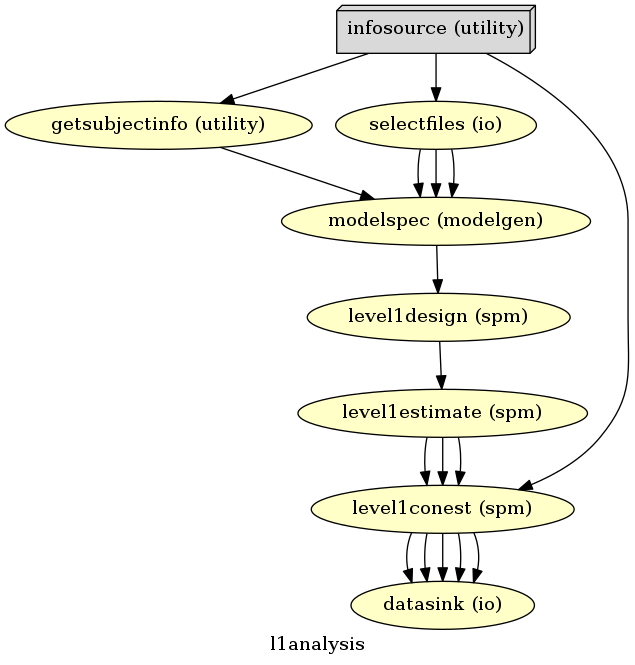

In [18]:
# Save the 1st-level analysis graph as png
l1analysis.write_graph(graph2use='colored', format='png', simple_form=True)

# Visualize the graph
from IPython.display import Image
Image(filename=f'{l1analysis.base_dir}/l1analysis/graph.png')

260805-13:55:39,4 nipype.workflow INFO:
	 Generated workflow graph: /output/workingdir/l1analysis/graph.png (graph2use=flat, simple_form=True).


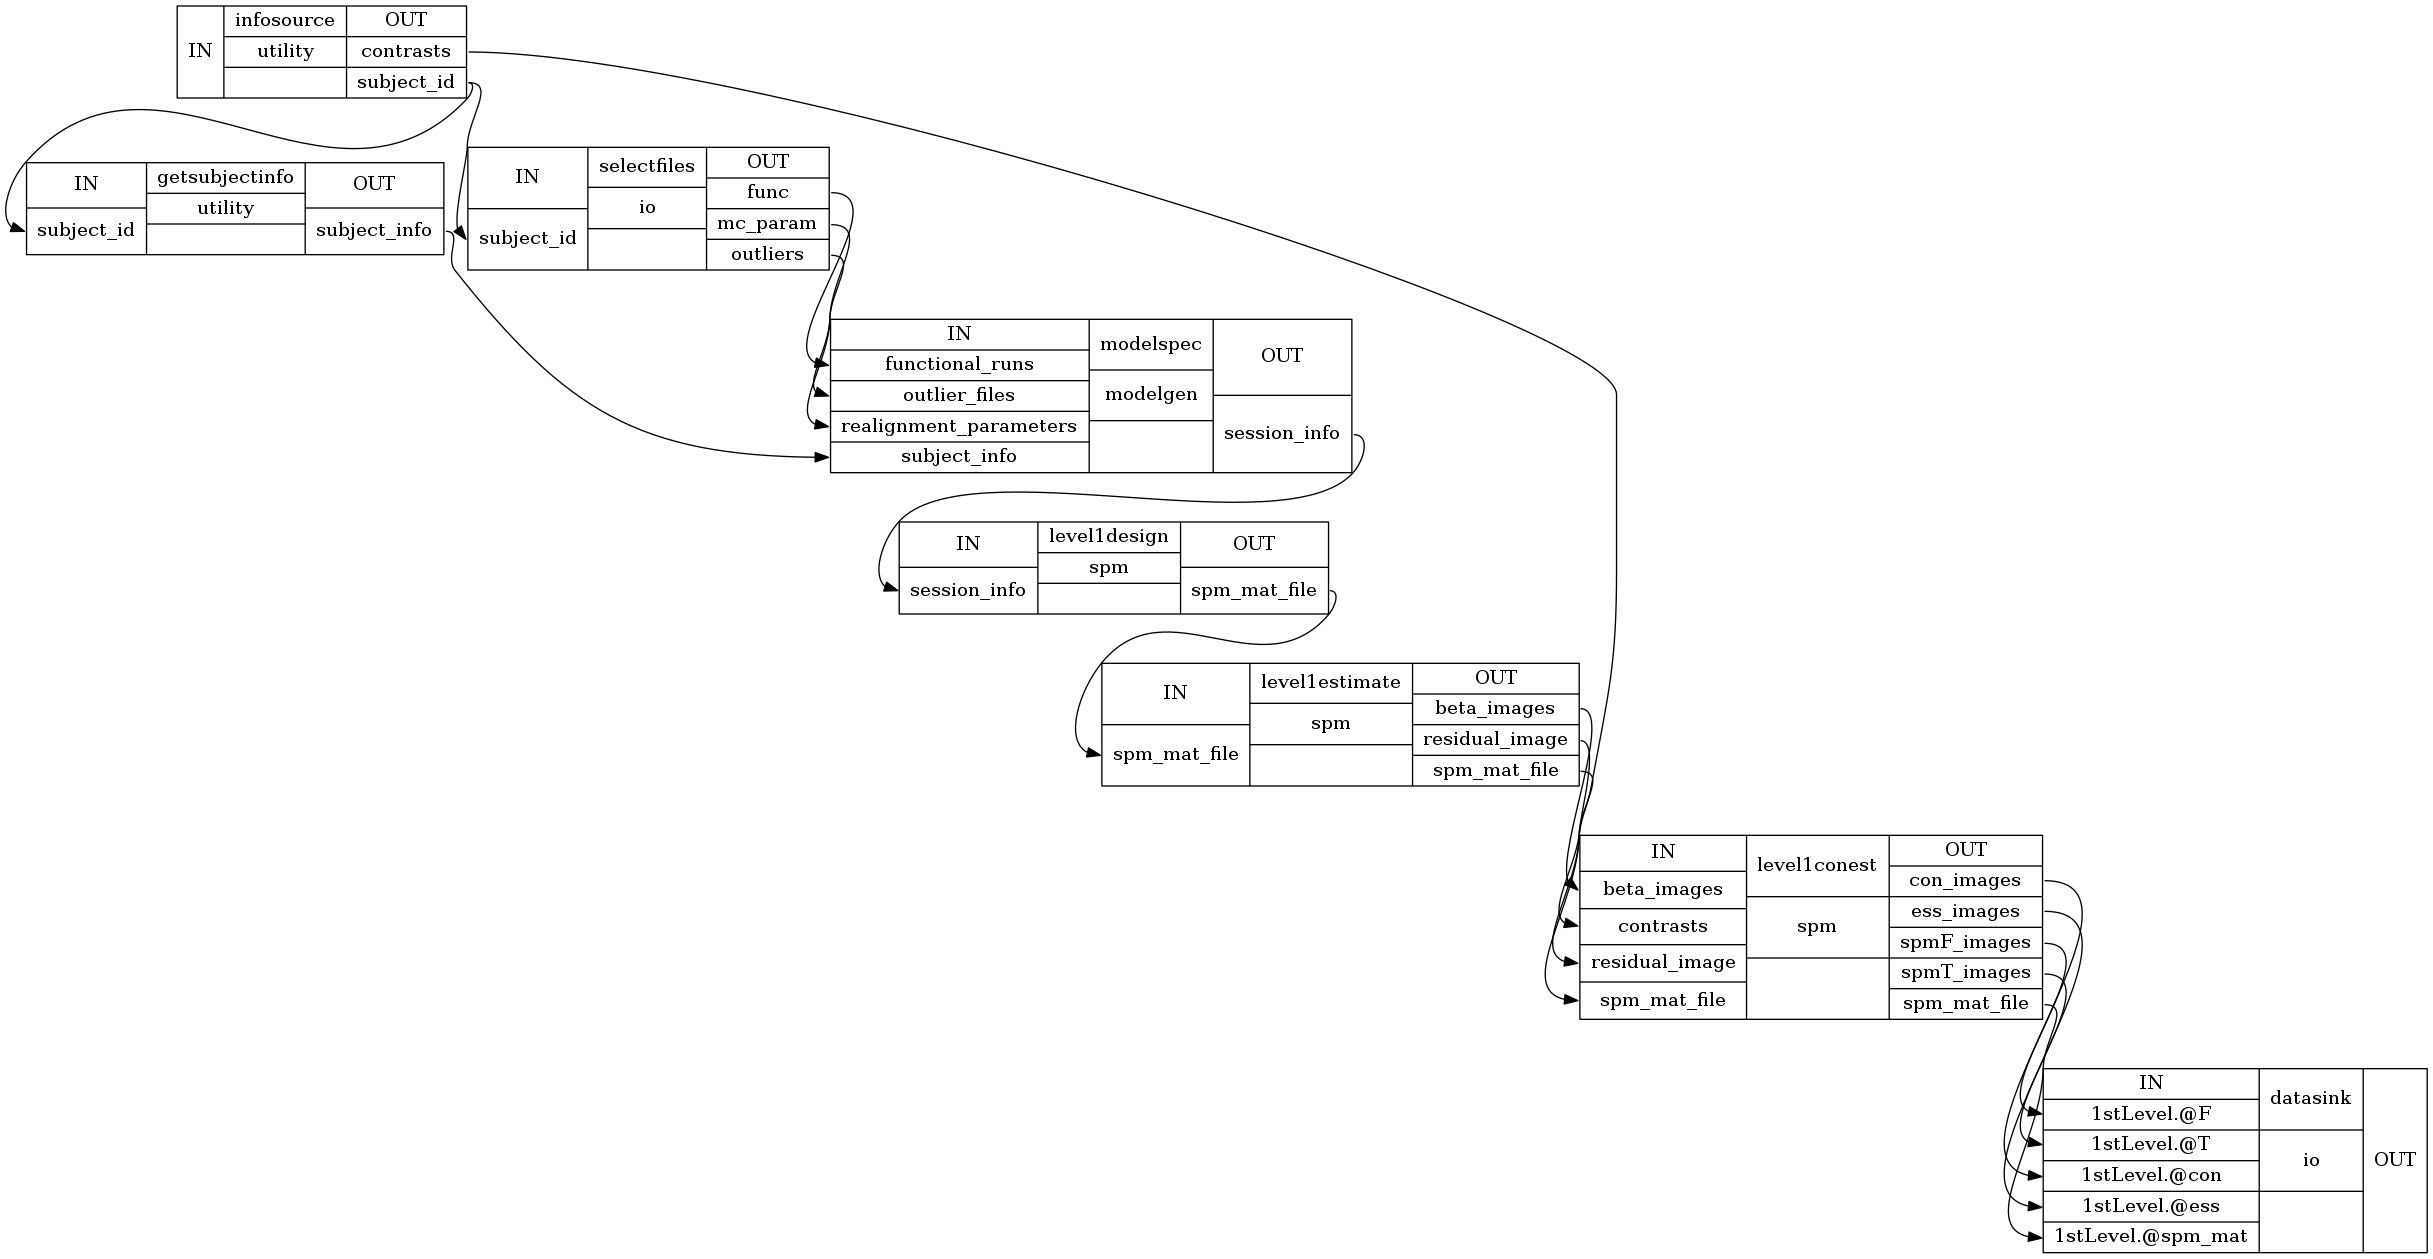

In [21]:
# show detailed workflow
l1analysis.write_graph(graph2use='flat', format='png', simple_form=True)
Image(filename=f'{l1analysis.base_dir}/l1analysis/graph_detailed.png')

##  Run the Workflow

Run the 1st-level analysis workflow. Run with 'Linear' plugin if multiprocessing failed.

In [22]:
l1analysis.run('Linear')

260805-13:55:51,72 nipype.workflow INFO:
	 Workflow l1analysis settings: ['check', 'execution', 'logging', 'monitoring']
260805-13:55:51,139 nipype.workflow INFO:
	 Running serially.
260805-13:55:51,141 nipype.workflow INFO:
	 [Node] Setting-up "l1analysis.getsubjectinfo" in "/output/workingdir/l1analysis/_subject_id_10/getsubjectinfo".
260805-13:55:51,144 nipype.workflow INFO:
	 [Node] Running "getsubjectinfo" ("nipype.interfaces.utility.wrappers.Function")
260805-13:55:51,159 nipype.workflow INFO:
	 [Node] Finished "l1analysis.getsubjectinfo".
260805-13:55:51,160 nipype.workflow INFO:
	 [Node] Setting-up "l1analysis.selectfiles" in "/output/workingdir/l1analysis/_subject_id_10/selectfiles".
260805-13:55:51,165 nipype.workflow INFO:
	 [Node] Running "selectfiles" ("nipype.interfaces.io.SelectFiles")
260805-13:55:51,173 nipype.workflow INFO:
	 [Node] Finished "l1analysis.selectfiles".
260805-13:55:51,174 nipype.workflow INFO:
	 [Node] Setting-up "l1analysis.modelspec" in "/output/worki

/opt/miniconda-latest/envs/neuro/lib/python3.6/site-packages/nipype/algorithms/modelgen.py:511: UserWarning: loadtxt: Empty input file: "/output/workingdir/l1analysis/_subject_id_08/modelspec/art.sub-08_ses-test_task-fingerfootlips_bold_outliers.txt"
  outindices = np.loadtxt(filename, dtype=int)


260805-13:57:07,292 nipype.workflow INFO:
	 [Node] Finished "l1analysis.level1design".
260805-13:57:07,294 nipype.workflow INFO:
	 [Node] Setting-up "l1analysis.level1estimate" in "/output/workingdir/l1analysis/_subject_id_08/level1estimate".
260805-13:57:07,303 nipype.workflow INFO:
	 [Node] Running "level1estimate" ("nipype.interfaces.spm.model.EstimateModel")
260805-13:57:20,55 nipype.workflow INFO:
	 [Node] Finished "l1analysis.level1estimate".
260805-13:57:20,57 nipype.workflow INFO:
	 [Node] Setting-up "l1analysis.level1conest" in "/output/workingdir/l1analysis/_subject_id_08/level1conest".
260805-13:57:20,123 nipype.workflow INFO:
	 [Node] Running "level1conest" ("nipype.interfaces.spm.model.EstimateContrast")
260805-13:57:28,740 nipype.workflow INFO:
	 [Node] Finished "l1analysis.level1conest".
260805-13:57:28,741 nipype.workflow INFO:
	 [Node] Setting-up "l1analysis.datasink" in "/output/workingdir/l1analysis/_subject_id_08/datasink".
260805-13:57:28,749 nipype.workflow INFO:


/opt/miniconda-latest/envs/neuro/lib/python3.6/site-packages/nipype/algorithms/modelgen.py:511: UserWarning: loadtxt: Empty input file: "/output/workingdir/l1analysis/_subject_id_07/modelspec/art.sub-07_ses-test_task-fingerfootlips_bold_outliers.txt"
  outindices = np.loadtxt(filename, dtype=int)


260805-13:57:36,623 nipype.workflow INFO:
	 [Node] Finished "l1analysis.level1design".
260805-13:57:36,625 nipype.workflow INFO:
	 [Node] Setting-up "l1analysis.level1estimate" in "/output/workingdir/l1analysis/_subject_id_07/level1estimate".
260805-13:57:36,688 nipype.workflow INFO:
	 [Node] Running "level1estimate" ("nipype.interfaces.spm.model.EstimateModel")
260805-13:57:47,824 nipype.workflow INFO:
	 [Node] Finished "l1analysis.level1estimate".
260805-13:57:47,825 nipype.workflow INFO:
	 [Node] Setting-up "l1analysis.level1conest" in "/output/workingdir/l1analysis/_subject_id_07/level1conest".
260805-13:57:47,841 nipype.workflow INFO:
	 [Node] Running "level1conest" ("nipype.interfaces.spm.model.EstimateContrast")
260805-13:57:57,115 nipype.workflow INFO:
	 [Node] Finished "l1analysis.level1conest".
260805-13:57:57,116 nipype.workflow INFO:
	 [Node] Setting-up "l1analysis.datasink" in "/output/workingdir/l1analysis/_subject_id_07/datasink".
260805-13:57:57,123 nipype.workflow INFO

/opt/miniconda-latest/envs/neuro/lib/python3.6/site-packages/nipype/algorithms/modelgen.py:511: UserWarning: loadtxt: Empty input file: "/output/workingdir/l1analysis/_subject_id_06/modelspec/art.sub-06_ses-test_task-fingerfootlips_bold_outliers.txt"
  outindices = np.loadtxt(filename, dtype=int)


260805-13:58:05,616 nipype.workflow INFO:
	 [Node] Finished "l1analysis.level1design".
260805-13:58:05,619 nipype.workflow INFO:
	 [Node] Setting-up "l1analysis.level1estimate" in "/output/workingdir/l1analysis/_subject_id_06/level1estimate".
260805-13:58:05,681 nipype.workflow INFO:
	 [Node] Running "level1estimate" ("nipype.interfaces.spm.model.EstimateModel")
260805-13:58:18,588 nipype.workflow INFO:
	 [Node] Finished "l1analysis.level1estimate".
260805-13:58:18,590 nipype.workflow INFO:
	 [Node] Setting-up "l1analysis.level1conest" in "/output/workingdir/l1analysis/_subject_id_06/level1conest".
260805-13:58:18,604 nipype.workflow INFO:
	 [Node] Running "level1conest" ("nipype.interfaces.spm.model.EstimateContrast")
260805-13:58:27,325 nipype.workflow INFO:
	 [Node] Finished "l1analysis.level1conest".
260805-13:58:27,326 nipype.workflow INFO:
	 [Node] Setting-up "l1analysis.datasink" in "/output/workingdir/l1analysis/_subject_id_06/datasink".
260805-13:58:27,334 nipype.workflow INFO

> Crashs information is stored in `.pklz` files. In case of a crash use the following command:
    
```bash
!nipypecli crash <Last generated .pklz file>
```

## Inspect output

Let's check the structure of the output folder, to see if we have everything we wanted to save. You should one image for each subject and contrast (``con_*.nii`` for T-contrasts and ``ess_*.nii`` for F-contrasts)

In [23]:
!tree /output/datasink/1stLevel

/output/datasink/1stLevel
├── sub-01
│   ├── con_0001.nii
│   ├── con_0002.nii
│   ├── con_0003.nii
│   ├── con_0004.nii
│   ├── con_0005.nii
│   ├── ess_0006.nii
│   ├── spmF_0006.nii
│   ├── SPM.mat
│   ├── spmT_0001.nii
│   ├── spmT_0002.nii
│   ├── spmT_0003.nii
│   ├── spmT_0004.nii
│   └── spmT_0005.nii
├── sub-02
│   ├── con_0001.nii
│   ├── con_0002.nii
│   ├── con_0003.nii
│   ├── con_0004.nii
│   ├── con_0005.nii
│   ├── ess_0006.nii
│   ├── spmF_0006.nii
│   ├── SPM.mat
│   ├── spmT_0001.nii
│   ├── spmT_0002.nii
│   ├── spmT_0003.nii
│   ├── spmT_0004.nii
│   └── spmT_0005.nii
├── sub-03
│   ├── con_0001.nii
│   ├── con_0002.nii
│   ├── con_0003.nii
│   ├── con_0004.nii
│   ├── con_0005.nii
│   ├── ess_0006.nii
│   ├── spmF_0006.nii
│   ├── SPM.mat
│   ├── spmT_0001.nii
│   ├── spmT_0002.nii
│   ├── spmT_0003.nii
│   ├── spmT_0004.nii
│   └── spmT_0005.nii
├── sub-04
│   ├── con_0001.nii
│   ├── con_0002.nii
│   ├── con_0003.nii
│   ├── con_0004.nii
│   ├── con_0005.nii
│  

```
/output/datasink/1stLevel/
├── sub-01/
│   ├── SPM.mat               <- Main model file (design, estimates, parameters)
│   ├── con_0001.nii          <- Effect size (beta-contrast) for contrast #1
│   ├── con_0002.nii          <- Effect size for contrast #2
│   ├── con_0003.nii          <- ...
│   ├── con_0004.nii
│   ├── con_0005.nii
│   ├── spmT_0001.nii         <- T-staistics map for contrast #1
│   ├── spmT_0002.nii
│   ├── spmT_0003.nii
│   ├── spmT_0004.nii
│   ├── spmT_0005.nii
│   ├── spmF_0006.nii         <- F-staistics map for F-contrast
│   └── ess_0006.nii          <- Explained Sum of Squares for F-contrast
├── sub-02/
│   └── ... (similarly)
...
└── sub-10/
    └── ... (similarly)
```

## Visualize results

Let's look at the contrasts of one subject that we've just computed. 

In [24]:
from nilearn.plotting import plot_stat_map

#Reminder the tests were 
test_to_number = {
    1: 'average',
    2: 'Finger',
    3: 'Foot',
    4: 'Lips',
    5: 'Foot > others',
    6: 'activation'
    }
subject_id = '01'
anatimg = f'/data/ds000114/derivatives/fmriprep/sub-{subject_id}/anat/sub-{subject_id}_t1w_preproc.nii.gz'

**Files `spmT_0001.nii` … `spmT_0005.nii`**

These are t-statistic maps for the same T-contrasts.

For each voxel we calculate: $t = \frac{c^T \hat{\beta}}{SE(c^T \beta)}$
where $SE$ – estimation of error variance (standart error);

This statistic tests the null hypothesis $H_0:c^T β = 0$. The greater $∣t∣$, the greater the effect's deviation from zero. The sign indicates the direction of the effect.

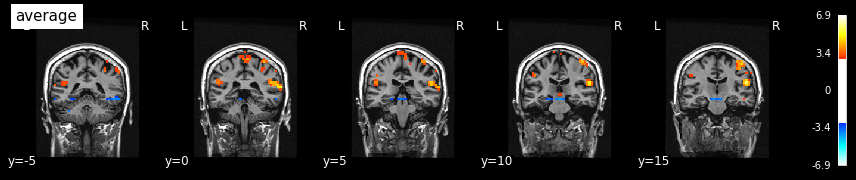

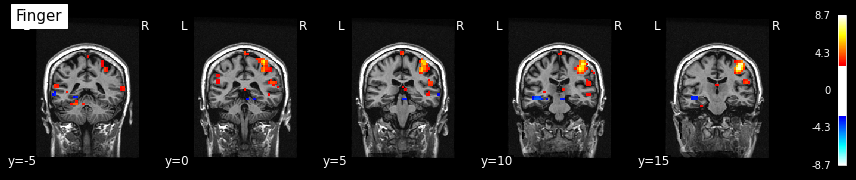

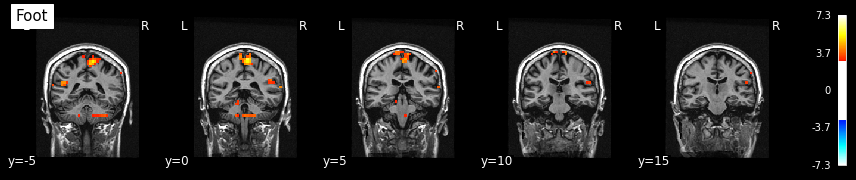

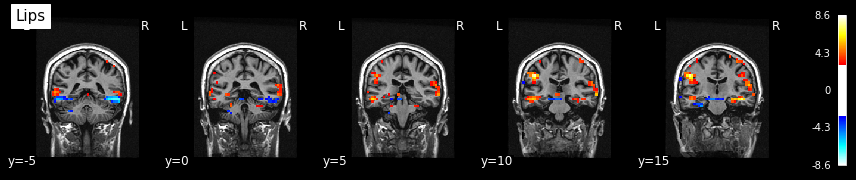

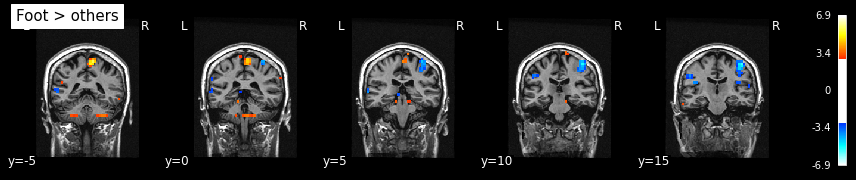

In [26]:
subject_id = '01'
 
anatimg = f'/data/ds000114/derivatives/fmriprep/sub-{subject_id}/anat/sub-{subject_id}_t1w_preproc.nii.gz'
for contrast_id in range(1, 6):
    plot_stat_map(
        f'/output/datasink/1stLevel/sub-{subject_id}/spmT_000{contrast_id}.nii', title=test_to_number[contrast_id],
        bg_img=anatimg, threshold=3, display_mode='y', cut_coords=(-5, 0, 5, 10, 15), dim=-1);

**File `spmF_0006.nii`**

This is an F-statistic map for a single F-contrast that tests the joint hypothesis. In our case $H_0$: all 3 conditions (Finger, Foot, Lips) do not have an effect simultaneously.

A full model (with 3 regressors) and a reduced model (without them) are built for this contrast. The F-statistic for each voxel is:
$$F=\frac{(ESS_{full} - ESS_{reduced})/(rank_{full}−rank_{reduced})}{ESS_{reduced}/(n−rank_full)}$$

where $ESS$ – Explained Sum of Squares and $n$ – number of time points.

The F-test answers the question: is there some activation in this voxel under at least one of the conditions? 
The result is a non-negative number with larger values indicate the presence of an effect.

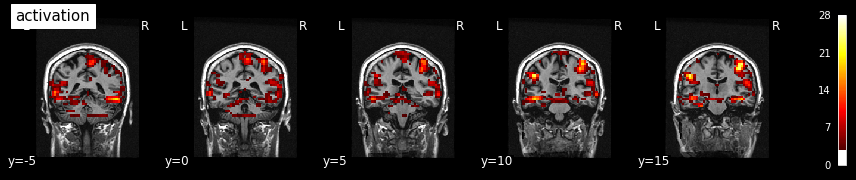

In [27]:
contrast_id = 6
subject_id = '01'

plot_stat_map(
        f'/output/datasink/1stLevel/sub-{subject_id}/spmF_000{contrast_id}.nii', title=test_to_number[contrast_id],
        bg_img=anatimg, threshold=3, display_mode='y', cut_coords=(-5, 0, 5, 10, 15), dim=-1);

**Sources:**


[General Linear Model for Neuroimaging](https://www.fmrib.ox.ac.uk/primers/appendices/glm.pdf)

[Convolution](https://practical-neuroimaging.github.io/on_convolution.html)

[General Linear Model (GLM)](http://mriquestions.com/general-linear-model.html)


**Special thanks to Michael Notter for the wonderful [nipype tutorial](https://miykael.github.io/nipype_tutorial/)**